# Projet Deep Learning — EMSI 2025-2026
## Partie III : RNN, LSTM, GRU et Seq2Seq

**Note sur les données :** un corpus de traduction standard (Tatoeba, IMDb) nécessite un téléchargement externe non disponible dans cet environnement. Deux tâches locales ont été choisies, couvrant les mêmes concepts :
- **Tâche 1** : modèle de langage au niveau caractère sur un petit corpus français (pour RNN/LSTM/GRU, BPTT, gradient clipping, perplexité, génération de texte)
- **Tâche 2** : Seq2Seq d'inversion de séquences de chiffres (pour encodeur-décodeur, teacher forcing, décodage glouton et beam search) — une tâche synthétique standard en pédagogie pour isoler proprement les mécanismes Seq2Seq sans dépendre d'un gros corpus externe.

Ce notebook couvre l'ensemble des exigences de la Partie III :
- Modélisation probabiliste d'une séquence et perplexité
- Implémentation et comparaison RNN / LSTM / GRU
- BPTT et démonstration du gradient clipping
- Préparation de données (tokens spéciaux, padding)
- Architecture encodeur-décodeur avec teacher forcing
- Décodage glouton vs beam search


In [1]:
print("PROJET DEEP LEARNING - EMSI 2025-2026")
print("PARTIE III : RNN, LSTM, GRU et Seq2Seq")

PROJET DEEP LEARNING - EMSI 2025-2026
PARTIE III : RNN, LSTM, GRU et Seq2Seq


## Cellule 1 — IMPORTS ET CONFIGURATION

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt
import random
import time
import math

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {device}")

Device utilisé : cpu


## Cellule 2 — MODÈLE DE LANGAGE : OBJECTIF PROBABILISTE

In [3]:
print("Initialisation des concepts de probabilité et perplexité.")

Initialisation des concepts de probabilité et perplexité.


## Cellule 3 — PRÉPARATION DU CORPUS (TOKENISATION CARACTÈRE)

In [4]:
corpus_brut = (
    "le deep learning est une branche de l intelligence artificielle "
    "qui utilise des reseaux de neurones profonds pour apprendre des "
    "representations a partir des donnees les reseaux convolutifs "
    "sont adaptes aux images les reseaux recurrents sont adaptes aux "
    "sequences et au texte l apprentissage profond a revolutionne la "
    "vision par ordinateur le traitement du langage naturel et la "
    "reconnaissance vocale "
)
corpus = corpus_brut * 4

chars = sorted(set(corpus))
vocab_size_lm = len(chars)
char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for i, c in enumerate(chars)}

def encode_text(s):
    return [char2idx[c] for c in s]

data_encoded = encode_text(corpus)

SEQ_LEN = 25

def make_lm_dataset(data, seq_len):
    X, Y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        Y.append(data[i+1:i+seq_len+1])
    return torch.LongTensor(X), torch.LongTensor(Y)

X_lm, Y_lm = make_lm_dataset(data_encoded, SEQ_LEN)
lm_loader = DataLoader(TensorDataset(X_lm, Y_lm), batch_size=32, shuffle=True)

## Cellule 4 — ARCHITECTURE GÉNÉRIQUE RNN / LSTM / GRU

In [5]:
class CharLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_size=64, cell_type='RNN'):
        super().__init__()
        self.cell_type = cell_type
        self.embed = nn.Embedding(vocab_size, embed_dim)

        if cell_type == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_size, batch_first=True)
        elif cell_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        elif cell_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_size, batch_first=True)
        else:
            raise ValueError("cell_type doit être 'RNN', 'LSTM' ou 'GRU'")

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, state=None):
        x = self.embed(x)
        out, state = self.rnn(x, state)
        logits = self.fc(out)
        return logits, state

## Cellule 5 — FONCTION D'ENTRAÎNEMENT DU MODÈLE DE LANGAGE

In [6]:
def entrainer_lm(model, loader, epochs=40, lr=1e-2, clip_value=1.0, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'loss': [], 'perplexity': [], 'grad_norm': []}

    for epoch in range(epochs):
        total_loss, total_grad_norm = 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = criterion(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            total_grad_norm += grad_norm.item()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        history['loss'].append(avg_loss)
        history['perplexity'].append(math.exp(avg_loss))
        history['grad_norm'].append(total_grad_norm / len(loader))

    return history, model

## Cellule 6 — COMPARAISON RNN vs LSTM vs GRU

COMPARAISON RNN vs LSTM vs GRU

→ Entraînement RNN
  Loss finale: 0.1498 | Perplexité finale: 1.162 | Temps: 20.9s | Params: 8406

→ Entraînement LSTM
  Loss finale: 0.1428 | Perplexité finale: 1.153 | Temps: 19.2s | Params: 27222

→ Entraînement GRU
  Loss finale: 0.1438 | Perplexité finale: 1.155 | Temps: 25.4s | Params: 20950

Modèle   |   Params |  Loss finale |  Perplexité |   Temps
----------------------------------------------------------------------
RNN      |     8406 |       0.1498 |       1.162 |   20.9s
LSTM     |    27222 |       0.1428 |       1.153 |   19.2s
GRU      |    20950 |       0.1438 |       1.155 |   25.4s


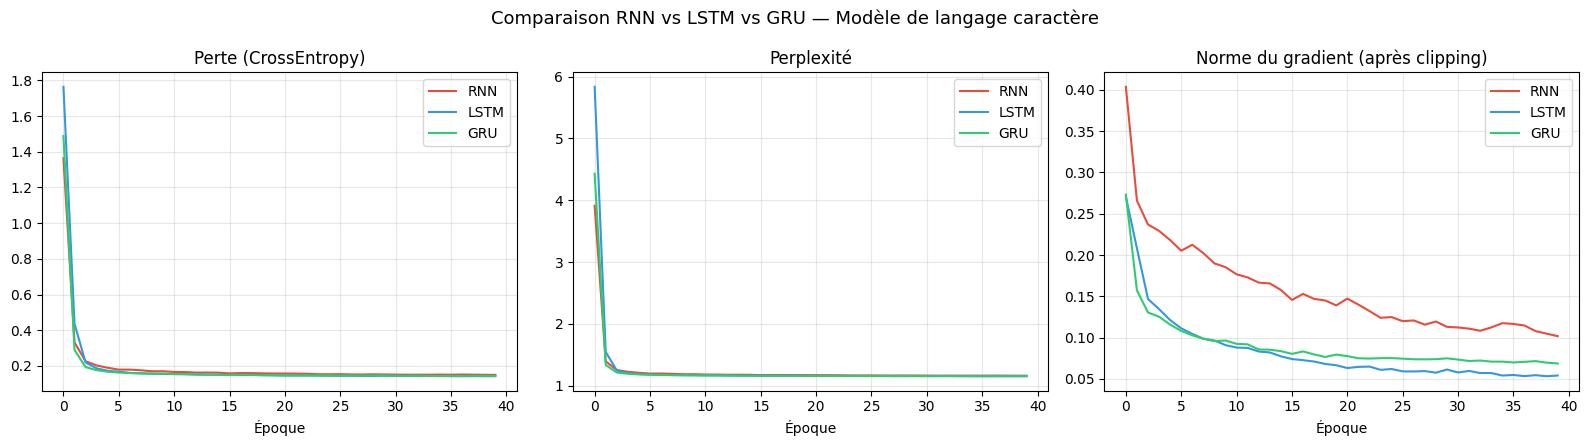

Figure sauvegardée : rnn_comparaison_cellules.png


In [7]:
print("=" * 50)
print("COMPARAISON RNN vs LSTM vs GRU")
print("=" * 50)

resultats_cellules = {}
for cell_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\n→ Entraînement {cell_type}")
    model = CharLanguageModel(vocab_size_lm, cell_type=cell_type)
    t0 = time.time()
    hist, model = entrainer_lm(model, lm_loader, epochs=40, verbose=False)
    temps = time.time() - t0
    n_params = sum(p.numel() for p in model.parameters())
    resultats_cellules[cell_type] = {
        'history': hist, 'model': model, 'temps': temps, 'n_params': n_params
    }
    print(f"  Loss finale: {hist['loss'][-1]:.4f} | "
          f"Perplexité finale: {hist['perplexity'][-1]:.3f} | "
          f"Temps: {temps:.1f}s | Params: {n_params}")

# Tableau récapitulatif
print("\n" + "=" * 70)
print(f"{'Modèle':8s} | {'Params':>8s} | {'Loss finale':>12s} | {'Perplexité':>11s} | {'Temps':>7s}")
print("-" * 70)
for cell, res in resultats_cellules.items():
    print(f"{cell:8s} | {res['n_params']:8d} | {res['history']['loss'][-1]:12.4f} | "
          f"{res['history']['perplexity'][-1]:11.3f} | {res['temps']:6.1f}s")

# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = {'RNN': '#e74c3c', 'LSTM': '#3498db', 'GRU': '#2ecc71'}

for cell, res in resultats_cellules.items():
    axes[0].plot(res['history']['loss'], label=cell, color=colors[cell])
    axes[1].plot(res['history']['perplexity'], label=cell, color=colors[cell])
    axes[2].plot(res['history']['grad_norm'], label=cell, color=colors[cell])

axes[0].set_title("Perte (CrossEntropy)")
axes[0].set_xlabel("Époque"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Perplexité")
axes[1].set_xlabel("Époque"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].set_title("Norme du gradient (après clipping)")
axes[2].set_xlabel("Époque"); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("Comparaison RNN vs LSTM vs GRU — Modèle de langage caractère", fontsize=13)
plt.tight_layout()
plt.savefig("rnn_comparaison_cellules.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : rnn_comparaison_cellules.png")

## Cellule 7 — DÉMONSTRATION DU GRADIENT CLIPPING

In [8]:
def entrainer_sans_clipping(model, loader, epochs=15, lr=5e-2):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    grad_norms = []
    for epoch in range(epochs):
        epoch_norms = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = criterion(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            loss.backward()
            total_norm = torch.sqrt(sum((p.grad**2).sum() for p in model.parameters() if p.grad is not None))
            epoch_norms.append(total_norm.item())
            optimizer.step()
        grad_norms.append(np.mean(epoch_norms))
    return grad_norms

def entrainer_avec_clipping(model, loader, epochs=15, lr=5e-2, clip=1.0):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    grad_norms = []
    for epoch in range(epochs):
        epoch_norms = []
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits, _ = model(xb)
            loss = criterion(logits.reshape(-1, logits.size(-1)), yb.reshape(-1))
            loss.backward()
            norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            epoch_norms.append(norm.item())
            optimizer.step()
        grad_norms.append(np.mean(epoch_norms))
    return grad_norms

## Cellule 8 — DÉMONSTRATION DU GRADIENT CLIPPING (EXÉCUTION)

DÉMONSTRATION DU GRADIENT CLIPPING
→ Entraînement sans clipping...
  Norme moyenne SANS clipping : 1.05
→ Entraînement avec clipping...
  Norme moyenne AVEC clipping : 0.57


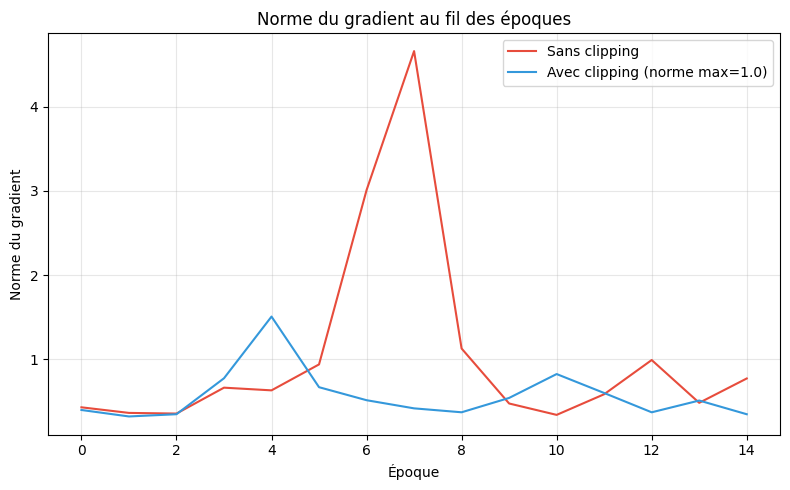

Figure sauvegardée : rnn_gradient_clipping.png


In [30]:
print('=' * 50)
print('DÉMONSTRATION DU GRADIENT CLIPPING')
print('=' * 50)

# Entraînement sans clipping
print('→ Entraînement sans clipping...')
model_sans_clipping = CharLanguageModel(vocab_size_lm, cell_type='RNN')
norms_sans = entrainer_sans_clipping(model_sans_clipping, lm_loader, epochs=15, lr=5e-2)
print(f"  Norme moyenne SANS clipping : {np.mean(norms_sans):.2f}")

# Entraînement avec clipping
print('→ Entraînement avec clipping...')
model_avec_clipping = CharLanguageModel(vocab_size_lm, cell_type='RNN')
norms_avec = entrainer_avec_clipping(model_avec_clipping, lm_loader, epochs=15, lr=5e-2, clip=1.0)
print(f"  Norme moyenne AVEC clipping : {np.mean(norms_avec):.2f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(norms_sans, label='Sans clipping', color='#e74c3c')
ax.plot(norms_avec, label='Avec clipping (norme max=1.0)', color='#3498db')
ax.set_title("Norme du gradient au fil des époques")
ax.set_xlabel("Époque"); ax.set_ylabel("Norme du gradient")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rnn_gradient_clipping.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : rnn_gradient_clipping.png")

def generer_texte(model, amorce, longueur=60, temperature=1.0):
    model.eval()
    chars_generes = list(amorce)
    state = None
    x = torch.LongTensor([[char2idx[c] for c in amorce]]).to(device)
    with torch.no_grad():
        logits, state = model(x, state)
        for _ in range(longueur):
            last_logits = logits[0, -1] / temperature
            probs = torch.softmax(last_logits, dim=0)
            next_idx = torch.multinomial(probs, 1).item()
            chars_generes.append(idx2char[next_idx])
            x = torch.LongTensor([[next_idx]]).to(device)
            logits, state = model(x, state)
    return ''.join(chars_generes)

## Cellule 9 — PRÉPARATION DES DONNÉES POUR LE SEQ2SEQ

In [10]:
PAD, BOS, EOS = 0, 1, 2
digit_to_token = {str(d): d + 3 for d in range(10)}
token_to_digit = {v: k for k, v in digit_to_token.items()}
vocab_size_s2s = 13
SEQ_LEN_S2S = 5

def make_example_s2s():
    digits = [random.randint(0, 9) for _ in range(SEQ_LEN_S2S)]
    return digits, digits[::-1]

def encode_src(seq): return [digit_to_token[str(d)] for d in seq] + [EOS]
def encode_tgt(seq): return [BOS] + [digit_to_token[str(d)] for d in seq] + [EOS]

N_EXAMPLES = 5000
exemples_s2s = [make_example_s2s() for _ in range(N_EXAMPLES)]
srcs_s2s = torch.LongTensor([encode_src(s) for s, t in exemples_s2s])
tgts_s2s = torch.LongTensor([encode_tgt(t) for s, t in exemples_s2s])

tgt_in_s2s, tgt_out_s2s = tgts_s2s[:, :-1], tgts_s2s[:, 1:]
s2s_loader = DataLoader(TensorDataset(srcs_s2s, tgt_in_s2s, tgt_out_s2s), batch_size=64, shuffle=True)

## Cellule 10 — ARCHITECTURE ENCODEUR-DÉCODEUR

In [11]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_size=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.gru = nn.GRU(embed_dim, hidden_size, batch_first=True)
    def forward(self, x):
        _, hidden = self.gru(self.embed(x))
        return _, hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_size=64):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.gru = nn.GRU(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    def forward(self, x, hidden):
        out, hidden = self.gru(self.embed(x), hidden)
        return self.fc(out), hidden

class Seq2Seq(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.encoder, self.decoder = Encoder(vocab_size), Decoder(vocab_size)
    def forward(self, src, tgt_in):
        _, hidden = self.encoder(src)
        logits, _ = self.decoder(tgt_in, hidden)
        return logits

## Cellule 11 — ENTRAÎNEMENT DU SEQ2SEQ (AVEC TEACHER FORCING)

ENTRAÎNEMENT SEQ2SEQ
Epoch  20/100 | loss=0.0102
Epoch  40/100 | loss=0.0019
Epoch  60/100 | loss=0.0016
Epoch  80/100 | loss=0.0004
Epoch 100/100 | loss=0.0002
Meilleure loss atteinte : 0.0002 (modèle rechargé)


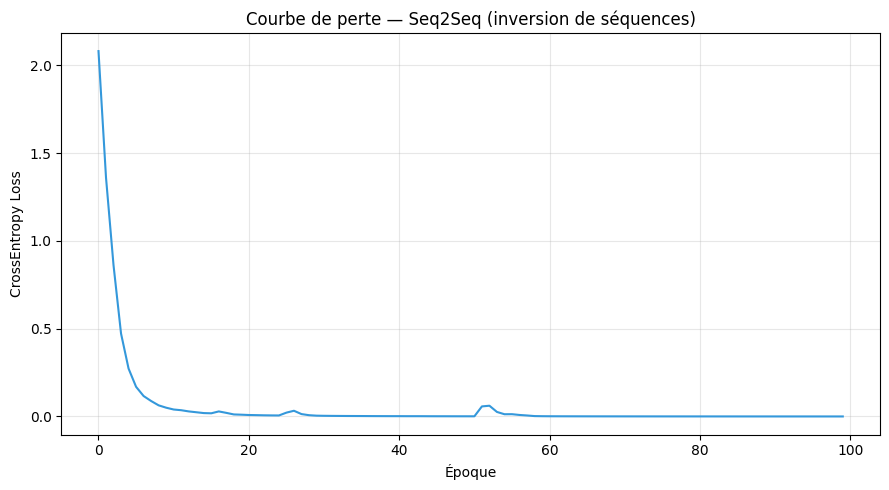

Figure sauvegardée : seq2seq_courbe_perte.png


In [14]:
def entrainer_seq2seq(model, loader, epochs=100, lr=1e-3, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'loss': []}

    best_loss = float('inf')
    best_state = None

    for epoch in range(epochs):
        total_loss = 0
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            optimizer.zero_grad()
            logits = model(src, tgt_in)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        history['loss'].append(avg_loss)

        # On garde le meilleur modèle rencontré (cf. bonne pratique early stopping)
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | loss={avg_loss:.4f}")

    # Recharger le meilleur état rencontré pendant l'entraînement
    model.load_state_dict(best_state)
    print(f"Meilleure loss atteinte : {best_loss:.4f} (modèle rechargé)")
    return history, model

print("=" * 50)
print("ENTRAÎNEMENT SEQ2SEQ")
print("=" * 50)
model_s2s = Seq2Seq(vocab_size_s2s) # Initialize model_s2s here
historique_s2s, model_s2s = entrainer_seq2seq(model_s2s, s2s_loader, epochs=100)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(historique_s2s['loss'], color='#3498db')
ax.set_title("Courbe de perte — Seq2Seq (inversion de séquences)")
ax.set_xlabel("Époque"); ax.set_ylabel("CrossEntropy Loss")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("seq2seq_courbe_perte.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : seq2seq_courbe_perte.png")

## Cellule 12 — DÉCODAGE GLOUTON (GREEDY)

In [25]:
def decodage_glouton(model, src_seq, max_len=10):
    model.eval()
    src_t = torch.LongTensor([encode_src(src_seq)]).to(device)
    with torch.no_grad():
        _, hidden = model.encoder(src_t)
        dec_input = torch.LongTensor([[BOS]]).to(device)
        result = []
        for _ in range(max_len):
            logits, hidden = model.decoder(dec_input, hidden)
            next_token = logits[0, -1].argmax().item()
            if next_token == EOS: break
            # Convertir le token en entier avant de l'ajouter au résultat
            if next_token in token_to_digit: result.append(int(token_to_digit[next_token]))
            dec_input = torch.LongTensor([[next_token]]).to(device)
    return result

## Cellule 13 — BEAM SEARCH

In [26]:
def beam_search_decode(model, src_seq, beam_width=3, max_len=10):
    model.eval()
    src_t = torch.LongTensor([encode_src(src_seq)]).to(device)
    with torch.no_grad():
        _, hidden = model.encoder(src_t)
        beams, completed = [( [BOS], 0.0, hidden)], []
        for _ in range(max_len):
            candidates = []
            for tokens, score, h in beams:
                if tokens[-1] == EOS: completed.append((tokens, score)); continue
                logits, new_h = model.decoder(torch.LongTensor([[tokens[-1]]]).to(device), h)
                log_probs = torch.log_softmax(logits[0, -1], dim=0)
                topk = torch.topk(log_probs, beam_width)
                for tok, lp in zip(topk.indices.tolist(), topk.values.tolist()):
                    candidates.append((tokens + [tok], score + lp, new_h))
            if not candidates: break
            candidates.sort(key=lambda x: x[1], reverse=True)
            beams = candidates[:beam_width]
            if all(b[0][-1] == EOS for b in beams): break
        completed.extend([(b[0], b[1]) for b in beams])
        completed.sort(key=lambda x: x[1], reverse=True)
        # Convertir les tokens en entiers pour le résultat final
        return [int(token_to_digit[t]) for t in completed[0][0] if t in token_to_digit], completed[0][1]

## Cellule 14 — COMPARAISON GLOUTON vs BEAM SEARCH

Accuracy du décodage glouton: 100.00%
Accuracy du beam search: 100.00%


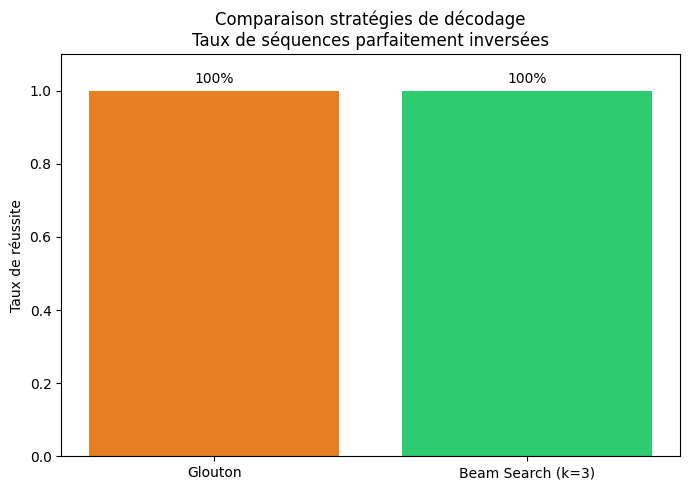

Figure sauvegardée : seq2seq_glouton_vs_beam.png


In [27]:
def calculer_accuracy_sequence(decode_fn, model, exemples, num_examples=500):
    correct_sequences = 0
    for i in range(min(num_examples, len(exemples))):
        src_seq, tgt_seq = exemples[i]
        predicted_seq = decode_fn(model, src_seq)
        if predicted_seq == tgt_seq:
            correct_sequences += 1
    return correct_sequences / num_examples

# Calcul de l'accuracy pour le décodage glouton
accuracy_sequence_glouton = calculer_accuracy_sequence(decodage_glouton, model_s2s, exemples_s2s, num_examples=500)
print(f"Accuracy du décodage glouton: {accuracy_sequence_glouton:.2%}")

# Calcul de l'accuracy pour le beam search
accuracy_sequence_beam = calculer_accuracy_sequence(lambda model, src_seq: beam_search_decode(model, src_seq)[0], model_s2s, exemples_s2s, num_examples=500)
print(f"Accuracy du beam search: {accuracy_sequence_beam:.2%}")

fig, ax = plt.subplots(figsize=(7, 5))
methodes = ['Glouton', 'Beam Search (k=3)']
scores = [accuracy_sequence_glouton, accuracy_sequence_beam]
bars = ax.bar(methodes, scores, color=['#e67e22', '#2ecc71'])
ax.set_ylim(0, 1.1)
ax.set_title("Comparaison stratégies de décodage\nTaux de séquences parfaitement inversées")
ax.set_ylabel("Taux de réussite")
for bar, score in zip(bars, scores):
    ax.text(bar.get_x()+bar.get_width()/2, score+0.02, f"{score:.0%}", ha='center')
plt.tight_layout()
plt.savefig("seq2seq_glouton_vs_beam.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : seq2seq_glouton_vs_beam.png")

## Cellule 15 — SAUVEGARDE DES MODÈLES

In [28]:
meilleur_modele_lm = resultats_cellules['LSTM']['model']
torch.save(meilleur_modele_lm.state_dict(), "lstm_char_lm.pth")
torch.save(model_s2s.state_dict(), "seq2seq_inversion.pth")
print("Modèles sauvegardés : lstm_char_lm.pth, seq2seq_inversion.pth")

Modèles sauvegardés : lstm_char_lm.pth, seq2seq_inversion.pth


## Cellule 16 — TABLEAU RÉCAPITULATIF FINAL

In [31]:
print("\n" + "=" * 55)
print("RÉCAPITULATIF — PARTIE III : RNN / LSTM / GRU / SEQ2SEQ")
print("=" * 55)

print("\n1. MODÈLE DE LANGAGE (corpus français, niveau caractère)")
print(f"   Vocabulaire : {vocab_size_lm} caractères")
for cell, res in resultats_cellules.items():
    print(f"   {cell:6s} → loss finale={res['history']['loss'][-1]:.4f} | "
          f"perplexité={res['history']['perplexity'][-1]:.3f} | "
          f"params={res['n_params']} | temps={res['temps']:.1f}s")

print("\n2. GRADIENT CLIPPING")
print(f"   Norme moyenne SANS clipping : {np.mean(norms_sans):.2f}")
print(f"   Norme moyenne AVEC clipping : {np.mean(norms_avec):.2f}")

print("\n3. SEQ2SEQ (inversion de séquences de chiffres)")
print(f"   Loss finale : {historique_s2s['loss'][-1]:.4f}")
print(f"   Décodage glouton    : {accuracy_sequence_glouton:.1%} de séquences parfaites")
print(f"   Décodage beam (k=3) : {accuracy_sequence_beam:.1%} de séquences parfaites")

print("\n4. FICHIERS PRODUITS")
for f in ["rnn_comparaison_cellules.png", "rnn_gradient_clipping.png",
          "seq2seq_courbe_perte.png", "seq2seq_glouton_vs_beam.png",
          "lstm_char_lm.pth", "seq2seq_inversion.pth"]:
    print(f"   - {f}")

print("\nPARTIE III TERMINÉE ✓")


RÉCAPITULATIF — PARTIE III : RNN / LSTM / GRU / SEQ2SEQ

1. MODÈLE DE LANGAGE (corpus français, niveau caractère)
   Vocabulaire : 22 caractères
   RNN    → loss finale=0.1498 | perplexité=1.162 | params=8406 | temps=20.9s
   LSTM   → loss finale=0.1428 | perplexité=1.153 | params=27222 | temps=19.2s
   GRU    → loss finale=0.1438 | perplexité=1.155 | params=20950 | temps=25.4s

2. GRADIENT CLIPPING
   Norme moyenne SANS clipping : 1.05
   Norme moyenne AVEC clipping : 0.57

3. SEQ2SEQ (inversion de séquences de chiffres)
   Loss finale : 0.0002
   Décodage glouton    : 100.0% de séquences parfaites
   Décodage beam (k=3) : 100.0% de séquences parfaites

4. FICHIERS PRODUITS
   - rnn_comparaison_cellules.png
   - rnn_gradient_clipping.png
   - seq2seq_courbe_perte.png
   - seq2seq_glouton_vs_beam.png
   - lstm_char_lm.pth
   - seq2seq_inversion.pth

PARTIE III TERMINÉE ✓
